<a href="https://colab.research.google.com/github/SAMeerAbhoyar/IPL-Data-Analysis/blob/main/IPL_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install kaggle

In [37]:
import os
os.environ['KAGGLE_TOKEN'] = 'your_new_token_here'  # paste new token after regenerating
os.environ['KAGGLE_USERNAME'] = 'sameerabh'  # your username

In [ ]:
!kaggle datasets download -d patrickb1912/ipl-complete-dataset-20082020
!unzip ipl-complete-dataset-20082020.zip

Dataset URL: https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020
License(s): DbCL-1.0
ipl-complete-dataset-20082020.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ipl-complete-dataset-20082020.zip
replace deliveries.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [21]:
import pandas as pd
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
print("Libraries loaded!")
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Libraries loaded!
Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [23]:
# Basic info
print(matches.columns.tolist())
print("\n")
print(matches.head())
print("\n")
print(matches.isnull().sum())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3       

In [24]:
# Remove matches with no result
matches.dropna(subset=['winner'], inplace=True)

# Fix season column (handles both '2007/08' and plain numbers)
matches['season'] = matches['season'].astype(str).str[:4].astype(int)

print("Data cleaned! Remaining matches:", len(matches))
print(matches['season'].unique())

Data cleaned! Remaining matches: 1090
[2007 2009 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


/tmp/ipykernel_6664/1366767188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wins.index, y=wins.values, palette='Blues_r')


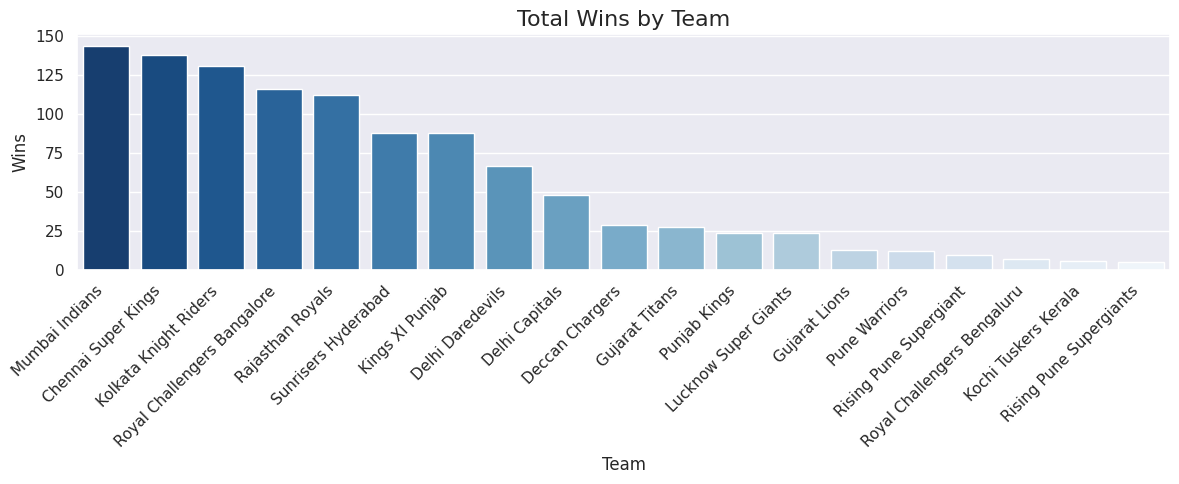

In [25]:
plt.figure(figsize=(12, 5))
wins = matches['winner'].value_counts()
sns.barplot(x=wins.index, y=wins.values, palette='Blues_r')
plt.title('Total Wins by Team', fontsize=16)
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

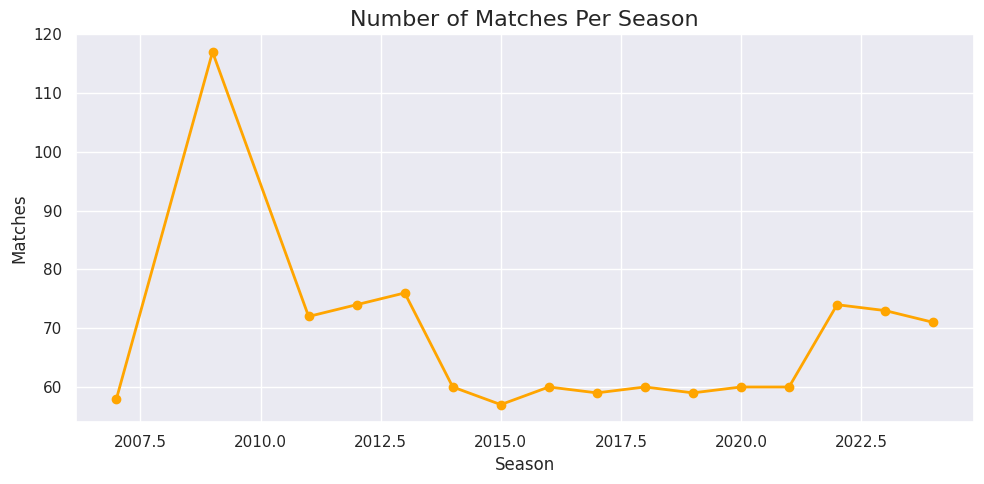

In [26]:
plt.figure(figsize=(10, 5))
matches.groupby('season').size().plot(kind='line', marker='o', color='orange', linewidth=2)
plt.title('Number of Matches Per Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Matches')
plt.tight_layout()
plt.show()

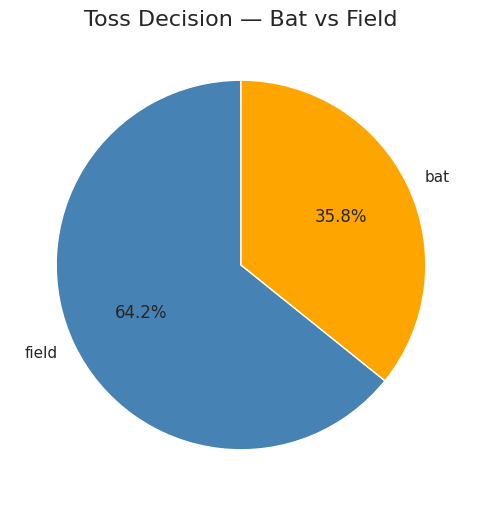

In [27]:
plt.figure(figsize=(6, 6))
matches['toss_decision'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['steelblue', 'orange'],
    startangle=90
)
plt.title('Toss Decision — Bat vs Field', fontsize=16)
plt.ylabel('')
plt.show()

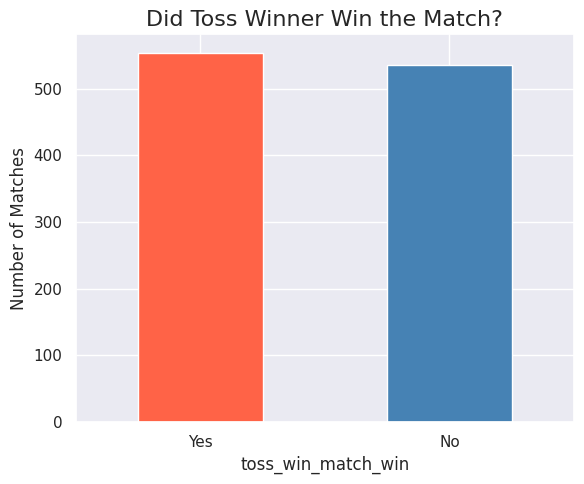

In [28]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']

plt.figure(figsize=(6, 5))
matches['toss_win_match_win'].value_counts().plot(
    kind='bar', color=['tomato', 'steelblue']
)
plt.title('Did Toss Winner Win the Match?', fontsize=16)
plt.xticks([0, 1], ['Yes', 'No'], rotation=0)
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6664/593751578.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r')


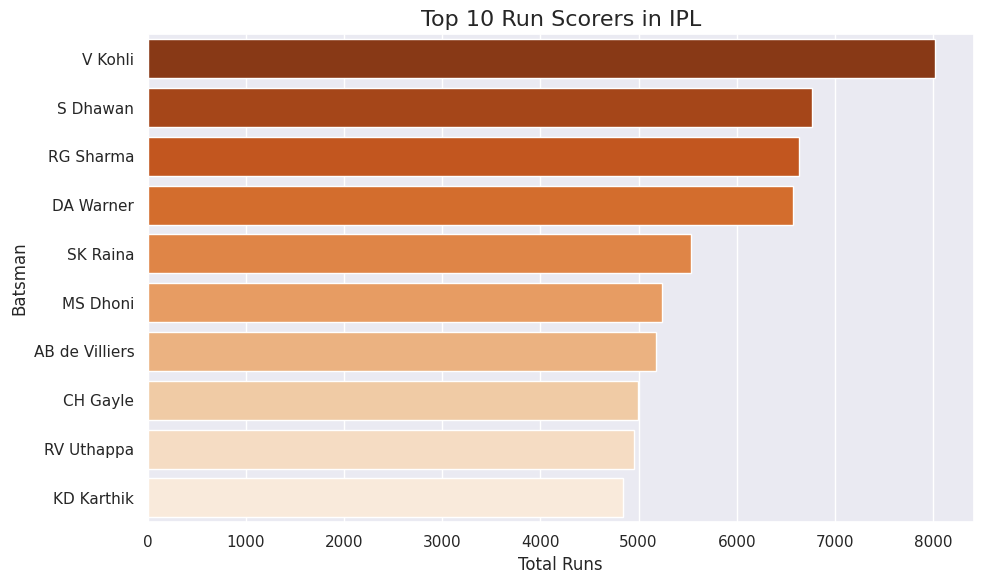

In [29]:
# Auto-detect correct column name
batter_col = 'batter' if 'batter' in deliveries.columns else 'batsman'
runs_col = 'batsman_runs' if 'batsman_runs' in deliveries.columns else 'batter_runs'

plt.figure(figsize=(10, 6))
top_batsmen = (
    deliveries.groupby(batter_col)[runs_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r')
plt.title('Top 10 Run Scorers in IPL', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6664/1087757428.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Reds_r')


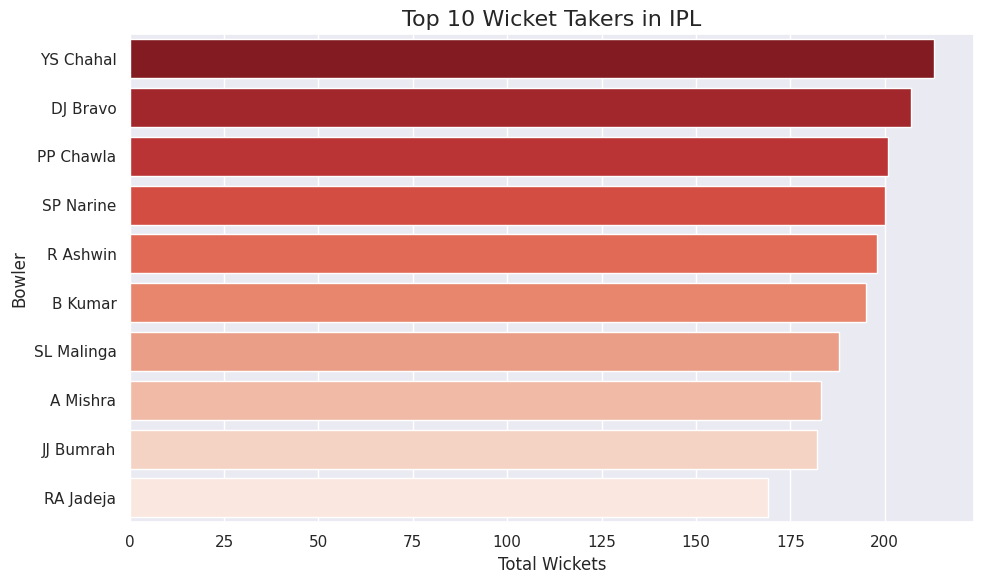

In [30]:
# Auto-detect correct column name
bowler_col = 'bowler' if 'bowler' in deliveries.columns else 'bowler'

plt.figure(figsize=(10, 6))
wickets = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = (
    wickets.groupby(bowler_col)['dismissal_kind']
    .count()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Reds_r')
plt.title('Top 10 Wicket Takers in IPL', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6664/1193982567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=over_runs.index, y=over_runs.values, palette='coolwarm')


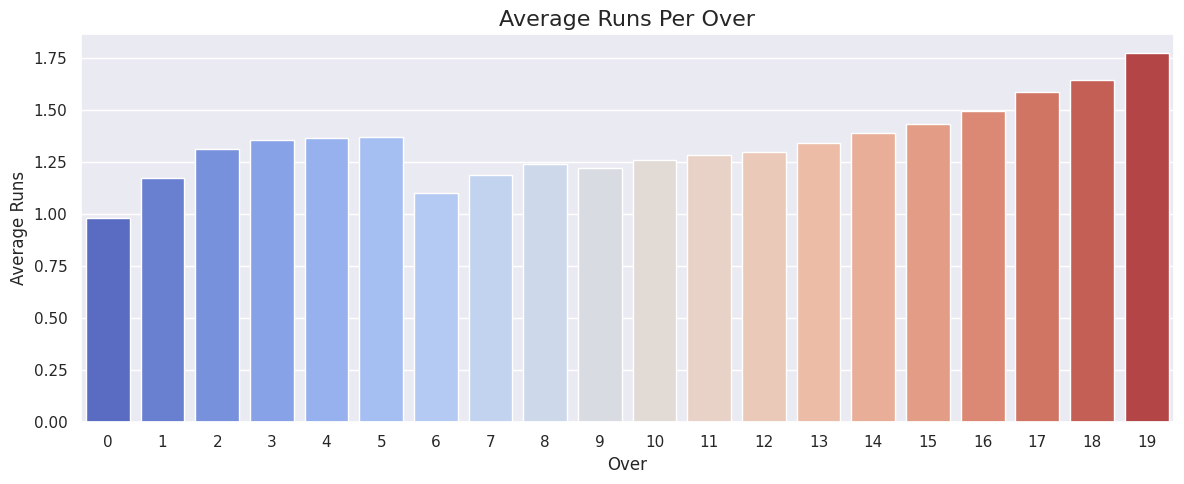

In [31]:
plt.figure(figsize=(12, 5))
over_runs = deliveries.groupby('over')['total_runs'].mean()
sns.barplot(x=over_runs.index, y=over_runs.values, palette='coolwarm')
plt.title('Average Runs Per Over', fontsize=16)
plt.xlabel('Over')
plt.ylabel('Average Runs')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6664/3237939347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='Greens_r')


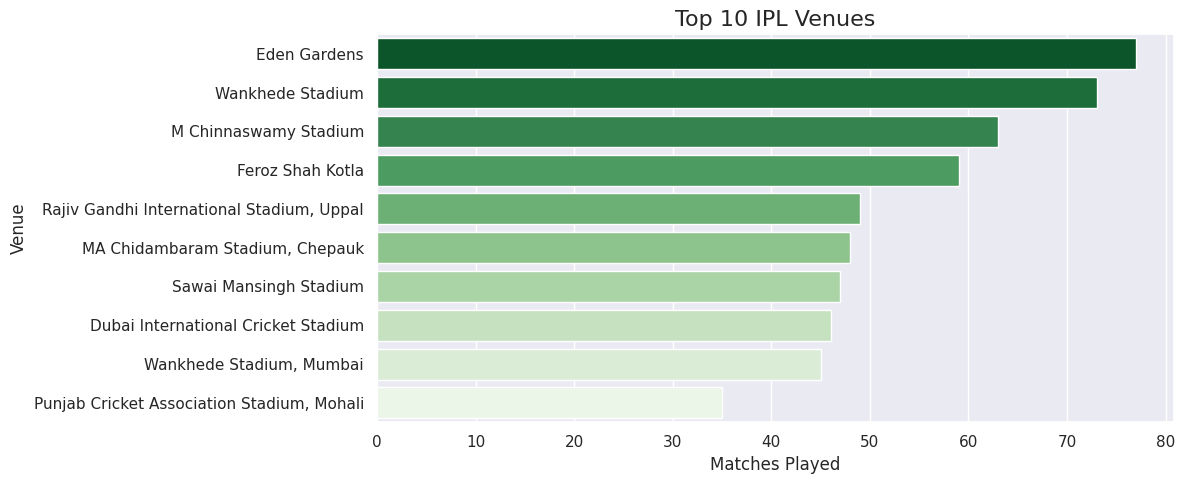

In [32]:
plt.figure(figsize=(12, 5))
top_venues = matches['venue'].value_counts().head(10)
sns.barplot(x=top_venues.values, y=top_venues.index, palette='Greens_r')
plt.title('Top 10 IPL Venues', fontsize=16)
plt.xlabel('Matches Played')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

In [33]:
print("===== IPL DATA ANALYSIS SUMMARY =====\n")
print(f"Total matches analyzed: {len(matches)}")
print(f"Total seasons: {matches['season'].nunique()}")
print(f"\nMost successful team: {matches['winner'].value_counts().index[0]} ({matches['winner'].value_counts().values[0]} wins)")
print(f"\nTop batsman: {top_batsmen.index[0]} ({top_batsmen.values[0]} runs)")
print(f"Top bowler: {top_bowlers.index[0]} ({top_bowlers.values[0]} wickets)")
print(f"\nToss helps win: {matches['toss_win_match_win'].value_counts(normalize=True)[True]*100:.1f}% of the time")

===== IPL DATA ANALYSIS SUMMARY =====

Total matches analyzed: 1090
Total seasons: 16

Most successful team: Mumbai Indians (144 wins)

Top batsman: V Kohli (8014 runs)
Top bowler: YS Chahal (213 wickets)

Toss helps win: 50.8% of the time
